Mounting the google drive for deepfake_capstone and double checking frames.zip is there

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/deepfake_capstone/

frames.zip


Initial idea here was to permanently unzip into the deepfake_capstone folder but that was going to take about 6-8 hours to fully execute which created an unfortunate bootleneck and I wanted to preserve my more robust computational allocation for later.

So instead it temporarily unzips into the local content run time and we have full access that way!

(Note: will have to do this for each ipynb for each week )

In [3]:
import os
if os.path.exists('/content/frames'):
  !rm -rf /content/frames/
!unzip -qo /content/drive/MyDrive/deepfake_capstone/frames.zip -d /content/

replace /content/frames/train/real/Celeb-real_id3_0006_frame_00000.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
A


Double checking the frame designations so I can confirm everything is there

In [7]:
import os
for split in ['train', 'val', 'test']:
  for label in ['real', 'fake']: #for looping through to get the len of the list above, then split amongst real v fake
    path = f'/content/frames/{split}/{label}'
    count = len(os.listdir(path))
    print(f"{split}/{label}: {count} frames")

train/real: 24856 frames
train/fake: 170930 frames
val/real: 4307 frames
val/fake: 30329 frames
test/real: 7116 frames
test/fake: 12939 frames


Little taste test of the frames because I have not actually seen them yet. And it is important that I know what I am expecting the models to look at and predict.

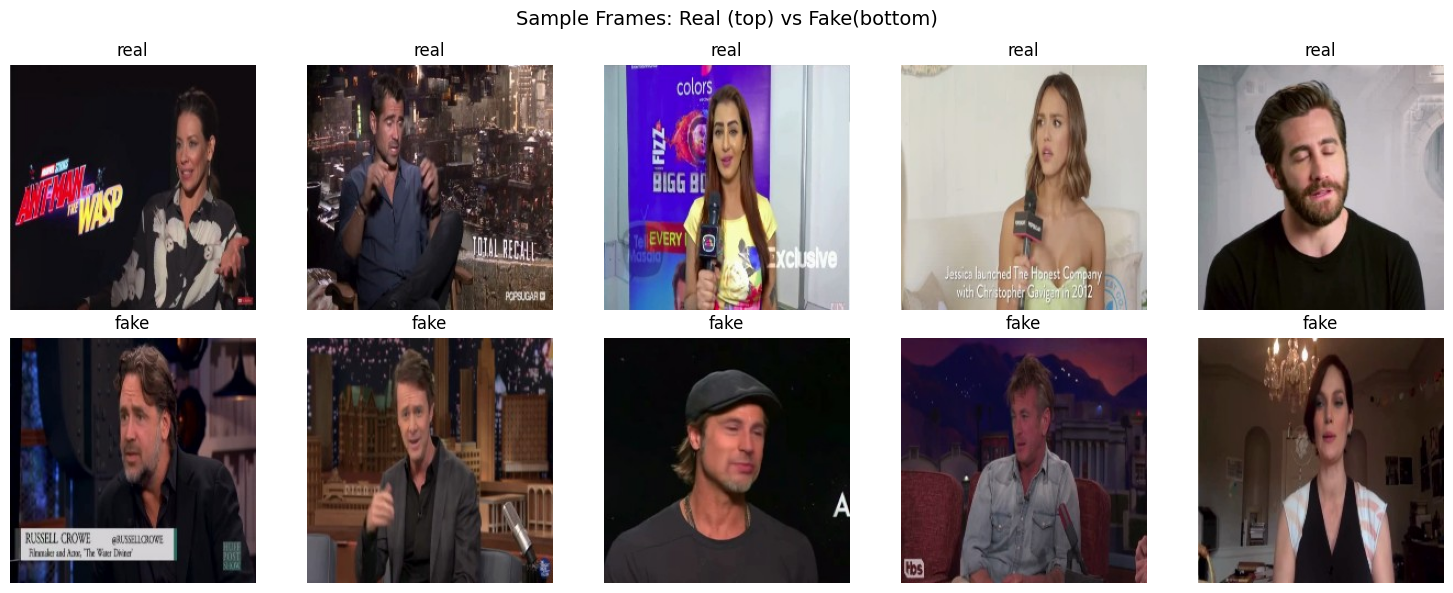

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
import random

#setting the seed
random.seed(301)

base = '/content/frames/train'
#plot to show 5 samples of real v fake
fig, axes = plt.subplots(2, 5, figsize = (15, 6))
fig.suptitle("Sample Frames: Real (top) vs Fake(bottom)", fontsize = 14)

for i, label in enumerate(['real', 'fake']):
  folder = os.path.join(base, label)
  samples = random.sample(os.listdir(folder), 5, set_seed ) #grabbing 5 random samples for viewing
  for j, fname in enumerate(samples):
    img = Image.open(os.path.join(folder, fname)) #opens img
    axes[i][j].imshow(img) #shows img in plot
    axes[i][j].set_title(label) #shows label alongside img
    axes[i][j].axis('off')

plt.tight_layout()
plt.show()

Double checking the image sizes. Error handling in case I run it out of order accidentally

In [11]:
from PIL import Image
import os
#just doing real because not actually checking every frame
path = '/content/frames/train/real'
if os.path.exists(path):
    sample = os.listdir(path)[:10] #even further im doing just 10 frames
    for f in sample:
        img = Image.open(os.path.join(path, f)) #opens image prints file name and size then looping
        print(f"{f}: {img.size}")
else:
    print("Path not found. Please ensure the unzip cell has finished running.")

Celeb-real_id55_0007_frame_00020.jpeg: (224, 224)
Celeb-real_id19_0003_frame_00200.jpeg: (224, 224)
YouTube-real_00290_frame_00440.jpeg: (224, 224)
Celeb-real_id2_0009_frame_00290.jpeg: (224, 224)
Celeb-real_id43_0007_frame_00190.jpeg: (224, 224)
YouTube-real_00028_frame_00130.jpeg: (224, 224)
Celeb-real_id6_0003_frame_00150.jpeg: (224, 224)
Celeb-real_id39_0003_frame_00120.jpeg: (224, 224)
YouTube-real_00248_frame_00380.jpeg: (224, 224)
Celeb-real_id23_0003_frame_00110.jpeg: (224, 224)


This continues getting the lay of the land with the spread of class distributions amongst real v fake and the frames set designations. From the looks of it I am going to be having the case of overfitting and insane accuracy (i.e false negatives rampantly) as my difficulties, if I predict.

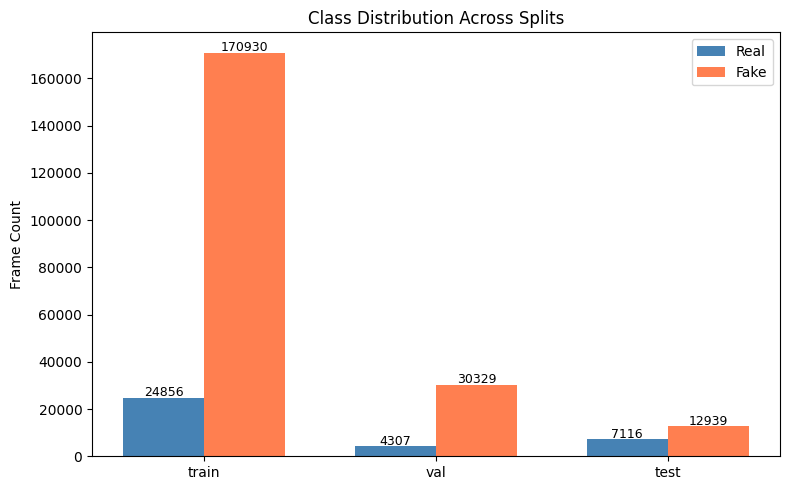

In [12]:
import matplotlib.pyplot as plt

splits = ['train', 'val', 'test']
real_counts = []
fake_counts = []

#getting the sizes for the bins. train, val, test
for split in splits:
    real_counts.append(len(os.listdir(f'/content/frames/{split}/real')))
    fake_counts.append(len(os.listdir(f'/content/frames/{split}/fake')))

#bar char plot
x = range(len(splits))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([i - width/2 for i in x], real_counts, width, label='Real', color='steelblue')
ax.bar([i + width/2 for i in x], fake_counts, width, label='Fake', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.set_ylabel('Frame Count')
ax.set_title('Class Distribution Across Splits')
ax.legend()

for i in x: #centering the count above each bar
    ax.text(i - width/2, real_counts[i] + 500, str(real_counts[i]), ha='center', fontsize=9)
    ax.text(i + width/2, fake_counts[i] + 500, str(fake_counts[i]), ha='center', fontsize=9)

plt.tight_layout()
plt.show()